# bigspy — MaNGA Galaxy Demo (manga-9195-3702)

Fit the central spaxel of a MaNGA galaxy with **Double Power Law SFH**.

Steps:
1. Load MaNGA datacube + drpall catalog
2. Extract central spectrum, apply MW extinction correction
3. SpecFit — kinematics + dust
4. MCMC — DPL SFH (τ, α, β) + metallicity
5. Visualization

In [1]:
import os, sys, time, numpy as np
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import astropy.io.fits as fits

from bigspy import SpecFit, MCMCFitter
from bigspy.mcmc.sfh import SFHBase, DelayedExponentialSFH
from bigspy.mcmc.priors import UniformPrior, LogUniformPrior
from bigspy.specfit import ccm_unred

print('Imports OK')

Imports OK


## 1. Load Data & Extract Central Spectrum

In [2]:
# Paths
REPO = os.path.abspath('..')
PCA_FILE  = os.path.join(REPO, 'template', 'BC03_Padova1994_chab_PCA_extend_new.fits')
SSP_FILE  = os.path.join(REPO, 'template', 'SSP_BC03_Padova1994_chab.fits')
CUBE_FILE = os.path.join(REPO, 'tests', 'manga-9195-3702-LOGCUBE.fits.gz')
DRPALL    = os.path.join(REPO, 'tests', 'drpall-v3_1_1.fits')
OUT_DIR   = os.path.join(REPO, 'out_manga_demo')
os.makedirs(OUT_DIR, exist_ok=True)

print('Data paths OK')

Data paths OK


In [3]:
# Load drpall catalog and get galaxy parameters
drp = fits.open(DRPALL)[1].data
mask_7977 = np.array(['9195' in str(p) and '3702' in str(p) for p in drp['PLATEIFU']])
row = drp[mask_7977][0]

z_sys = float(row['NSA_Z'])
ebv_mw = float(row['ebvgal'])
plateifu = str(row['PLATEIFU'])

print(f'PlateIFU:  {plateifu}')
print(f'Redshift:  z = {z_sys:.4f}')
print(f'E(B-V)_MW: {ebv_mw:.4f}')

PlateIFU:  9195-3702
Redshift:  z = 0.0642
E(B-V)_MW: 0.0787


Cube shape: (4563, 42, 42)
Wave range: 3622 – 10354 Å
Central spaxel: (21, 21)
Good pixels: 4558 / 4563


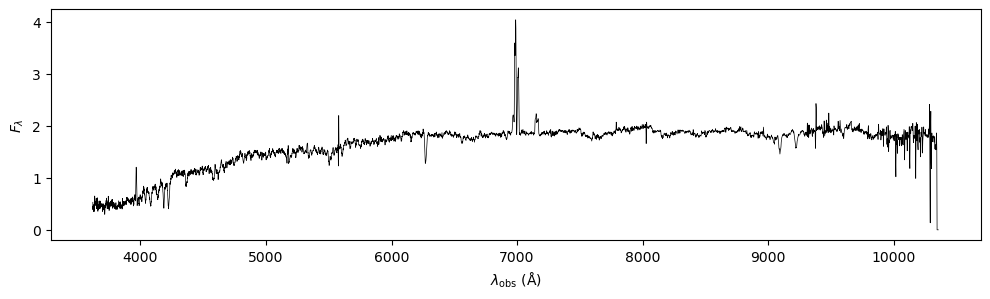

In [4]:
# Load datacube and extract central spaxel
cube = fits.open(CUBE_FILE)
wave_obs = cube['WAVE'].data.astype(np.float64)       # (4563,)
flux_cube = cube['FLUX'].data.astype(np.float64)       # (4563, 44, 44)
ivar_cube = cube['IVAR'].data.astype(np.float64)
mask_cube = cube['MASK'].data.astype(np.int32)

print(f'Cube shape: {flux_cube.shape}')
print(f'Wave range: {wave_obs[0]:.0f} – {wave_obs[-1]:.0f} Å')

# Central spaxel (22, 22) in a 44×44 IFU
cx, cy = flux_cube.shape[1] // 2, flux_cube.shape[2] // 2
spaxel_flux = flux_cube[:, cx, cy]
spaxel_ivar = ivar_cube[:, cx, cy]
spaxel_mask = mask_cube[:, cx, cy]

# Convert IVAR → error, handle masked pixels
spaxel_error = np.where(spaxel_ivar > 0, 1.0 / np.sqrt(spaxel_ivar), np.inf)
good_ok = (spaxel_ivar > 0) & (spaxel_mask == 0) & np.isfinite(spaxel_flux) & np.isfinite(spaxel_error)

print(f'Central spaxel: ({cx}, {cy})')
print(f'Good pixels: {good_ok.sum()} / {len(good_ok)}')

# Preview
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(wave_obs, spaxel_flux, 'k-', lw=0.5)
ax.set_xlabel(r'$\lambda_{\rm obs}\ (\mathrm{\AA})$')
ax.set_ylabel(r'$F_\lambda$')
plt.show()

## 2. MW Extinction Correction

Apply CCM (Cardelli, Clayton & Mathis 1989) to correct for Galactic foreground extinction.

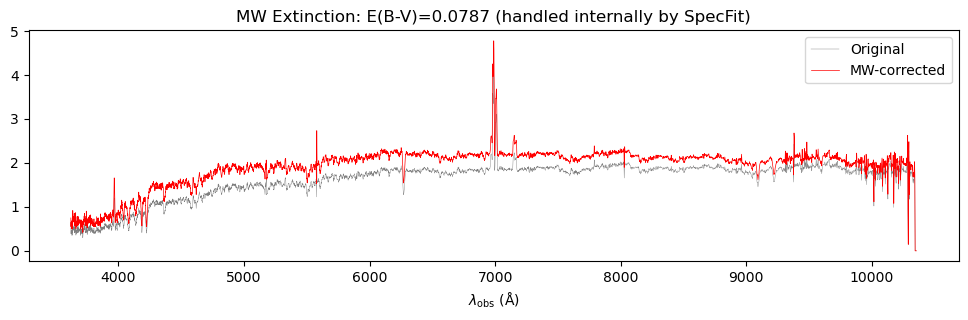

In [5]:
# Apply MW extinction correction for visualization
# (SpecFit handles this internally via ebv_mw parameter)
mw_correction = ccm_unred(wave_obs, ebv_mw)
flux_corr = spaxel_flux * mw_correction
error_corr = spaxel_error * mw_correction

# Quick check
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(wave_obs, spaxel_flux, 'k-', lw=0.3, alpha=0.5, label='Original')
ax.plot(wave_obs, flux_corr, 'r-', lw=0.5, label='MW-corrected')
ax.set_xlabel(r'$\lambda_{\rm obs}\ (\mathrm{\AA})$')
ax.legend()
ax.set_title(f'MW Extinction: E(B-V)={ebv_mw:.4f} (handled internally by SpecFit)')
plt.show()

## 3. SpecFit — Kinematics + Dust

In [6]:
%%time
sf = SpecFit(PCA_FILE)
specfit = sf.fit(
    wave=wave_obs,
    flux=spaxel_flux,
    error=spaxel_error,
    mask=1.0 - good_ok.astype(float),    # 0=good (original convention)
    z_sys=z_sys,
    mode='mode2',
    ebv_mw=ebv_mw,
)

print(f'v_e     = {specfit.ve[0]:8.1f} ± {specfit.ve[1]:5.1f} km/s')
print(f'v_d     = {specfit.vd[0]:8.1f} ± {specfit.vd[1]:5.1f} km/s')
print(f'E(B-V)  = {specfit.ebv[0]:6.4f} ± {specfit.ebv[1]:5.4f}')
print(f'p1 = {specfit.p1:.4f}   p2 = {specfit.p2:.4f}')

v_e     =     87.2 ±   3.0 km/s
v_d     =    144.8 ±   3.3 km/s
E(B-V)  = 0.2345 ± 0.0061
p1 = 0.8325   p2 = -0.0868
CPU times: user 462 ms, sys: 5.93 ms, total: 468 ms
Wall time: 193 ms


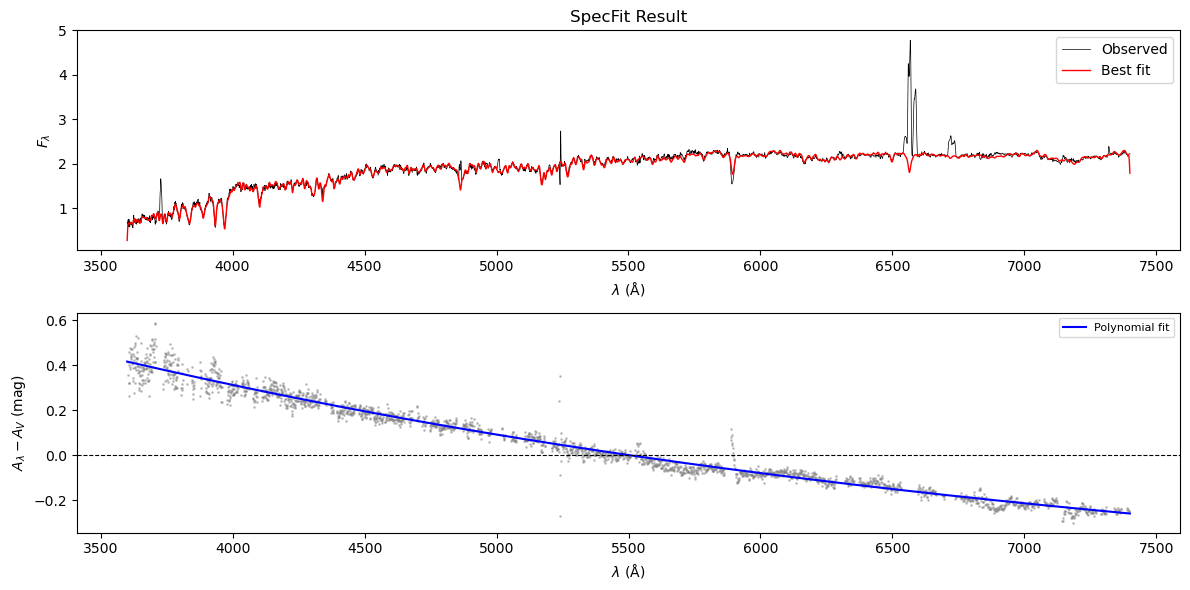

In [7]:
# SpecFit plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
w = specfit.wave_prep
ax1.plot(w, specfit.flux_prep, 'k-', lw=0.5, label='Observed')
if specfit.bestfit is not None:
    ax1.plot(w, specfit.bestfit, 'r-', lw=1, label='Best fit')
ax1.set_xlabel(r'$\lambda\ (\mathrm{\AA})$'); ax1.set_ylabel(r'$F_\lambda$')
ax1.legend(); ax1.set_title('SpecFit Result')

w_dust = np.linspace(3600, 7400, 500)
x_dust = 10000.0 / w_dust; xv = 10000.0 / 5500.0
A_dust = specfit.p1 * (x_dust - xv) + specfit.p2 * (x_dust**2 - xv**2)
if specfit._dust_data_wave is not None:
    ax2.scatter(specfit._dust_data_wave, specfit._dust_data_A, s=1, c='gray', alpha=0.4)
ax2.plot(w_dust, A_dust, 'b-', lw=1.5, label='Polynomial fit')
ax2.axhline(0.0, color='k', ls='--', lw=0.8)
ax2.set_xlabel(r'$\lambda\ (\mathrm{\AA})$'); ax2.set_ylabel(r'$A_\lambda - A_V$ (mag)')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Double Power Law SFH

$$\mathrm{SFR}(t) = \frac{1}{(t/\tau)^\alpha + (t/\tau)^{-\beta}}$$

In [8]:
class DoublePowerLawSFH(SFHBase):
    """SFR(t) = 1 / ((t/τ)^α + (t/τ)^(−β))"""
    n_params = 3
    param_names = ['tau', 'alpha', 'beta']
    default_priors = {
        'tau':   LogUniformPrior(0.1, 13.0),
        'alpha': LogUniformPrior(0.1, 1000.0),
        'beta':  LogUniformPrior(0.1, 1000.0),
    }
    def __init__(self, tau, alpha, beta, age_universe=13.8):
        self.tau, self.alpha, self.beta = float(tau), float(alpha), float(beta)
        self.age_universe = float(age_universe)
    def evaluate(self, timegrid):
        t = np.max(timegrid) - timegrid
        t = np.where(t <= 0, 1e-10, t)
        x = t / self.tau
        sfr = 1.0 / (x**self.alpha + x**(-self.beta))
        sfr[timegrid > self.age_universe] = 0.0
        return sfr

print(f'DPL SFH defined: {DoublePowerLawSFH.n_params} params')

DPL SFH defined: 3 params


## 5. MCMC — Stellar Population Inference

In [9]:
mc_dpl = MCMCFitter(
    use_jax=True,
    ssp_fits=SSP_FILE,
    specfit_result=specfit,
    sfh_model=DoublePowerLawSFH,
    wave_range=(3600, 7400),
)
print(f'Likelihood ndof = {mc_dpl.likelihood.ndof}')

Likelihood ndof = 2471


In [10]:
%%time
N_LIVE = 400
chain_dir = os.path.join(OUT_DIR, 'chains_dpl')
res = mc_dpl.run(
    n_live=N_LIVE,
    chain_dir=chain_dir,
    priors={
        'logZsun': UniformPrior(-2.5, 0.5),
        'tau':     LogUniformPrior(0.1, 13.0),
        'alpha':   LogUniformPrior(0.1, 1000.0),
        'beta':    LogUniformPrior(0.1, 1000.0),
    },
)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-4e+03  394.45 [-4396.3076..-4396.3071]*| it/evals=9862/240369 eff=4.0676% N=299     
[ultranest] Likelihood function evaluations: 240387
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -4421 +- 0.1582
[ultranest] Effective samples strategy satisfied (ESS = 741.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.46, need <0.5)
[ultranest]   logZ error budget: single: 0.28 bs:0.16 tail:0.43 total:0.46 required:<0.50
[ultranest] done iterating.

logZ = -4420.724 +- 0.499
  single instance: logZ = -4420.724 +- 0.243
  bootstrapped   : logZ = -4420.722 +- 0.256
  tail           : logZ = +- 0.428
insert order U test : converged: True correlation: inf iterations

    tau                 : 12.9630│ ▁ ▁ ▁  ▁ ▁▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇│12.9999    12.9967 +- 0.0034
 

In [11]:
post = res.posterior
names = mc_dpl._sampler.param_names
best  = res.bestfit

print(f'Posterior samples: {len(post)}')
print(f'log Z = {res.log_evidence:.2f}')
print(f'\n{"Parameter":>12s}  {"Median":>10s}  {"68% CI":>25s}')
print('-' * 52)
for i, name in enumerate(names):
    lo, med, hi = np.percentile(post[:, i], [16, 50, 84])
    print(f'{name:>12s}  {med:10.4f}  [{lo:.4f}, {hi:.4f}]')
if 'logZsun' in best:
    Z = 0.02 * 10**best['logZsun']
    print(f'\nZ = {Z:.5f}  (Z_solar = 0.02)')

Posterior samples: 10171
log Z = -4420.72

   Parameter      Median                     68% CI
----------------------------------------------------
         tau     12.9977  [12.9939, 12.9995]
       alpha     51.4816  [50.6561, 52.3228]
        beta      2.4295  [2.2475, 2.6184]
     logZsun      0.1979  [0.1826, 0.2127]

Z = 0.03219  (Z_solar = 0.02)


## 6. Visualization

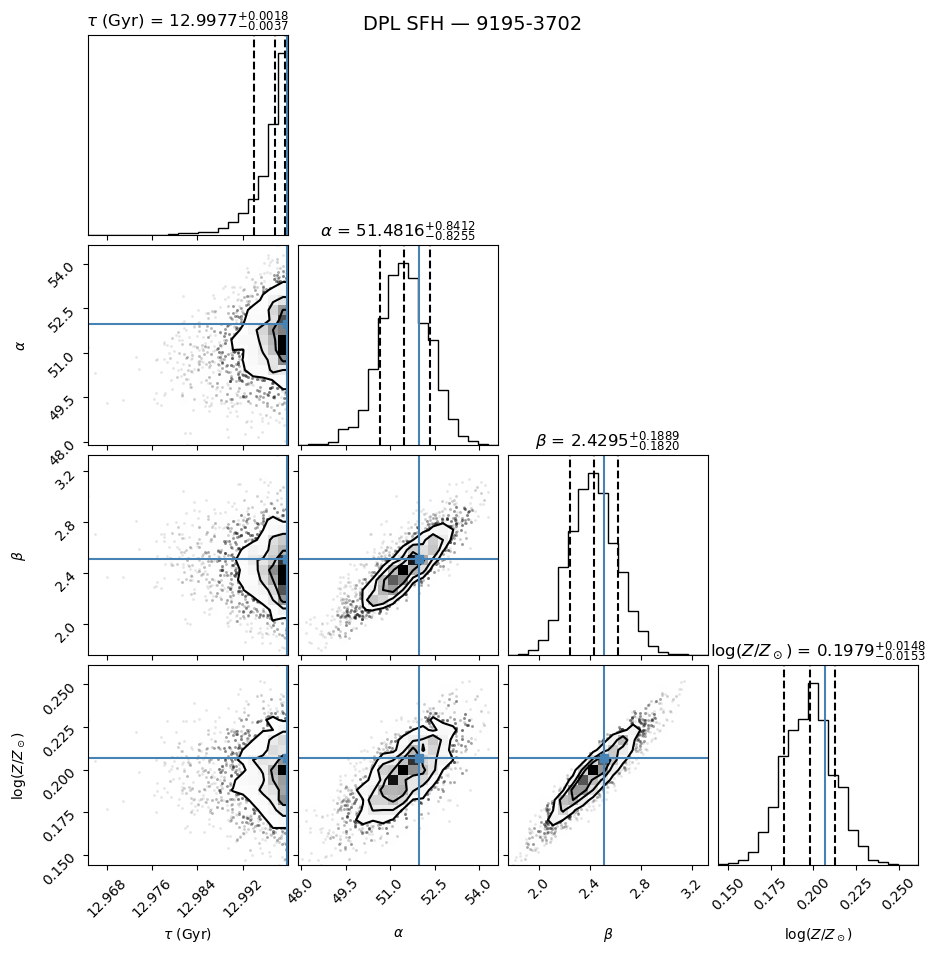

In [12]:
# Corner plot
from corner import corner as _corner
_label_map = {'logZsun': r'$\log(Z/Z_\odot)$', 'tau': r'$\tau$ (Gyr)',
              'alpha': r'$\alpha$', 'beta': r'$\beta$'}
labels = [_label_map.get(n, n) for n in names]
truths = [best[n] for n in names]

fig = _corner(post, labels=labels, truths=truths,
              quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt='.4f')
fig.suptitle(f'DPL SFH — {plateifu}', fontsize=14)
plt.show()

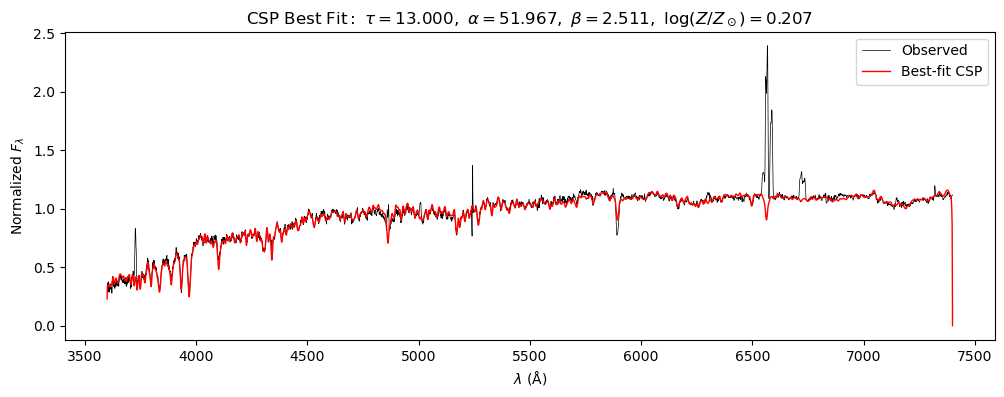

In [13]:
# Best-fit CSP
like = mc_dpl.likelihood
sfh_best = DoublePowerLawSFH(**{k: v for k, v in best.items() if k != 'logZsun'}, age_universe=13.8)
logZ = best.get('logZsun', 0.0)

csp = like.builder.build(logZ, sfh_best)
csp = like.broadener.apply(csp)
n = like._med5500(like.ssp.wave, csp, np.ones_like(csp, dtype=bool), like._n_range)
csp = csp / n; csp = like.dust.apply(csp)
csp_obs = np.interp(like.obs_wave, like.ssp.wave, csp, left=0.0, right=0.0)
n_obs = 1.0 / np.median(like.obs_flux[like.obs_mask])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(like.obs_wave, like.obs_flux * n_obs, 'k-', lw=0.5, label='Observed')
ax.plot(like.obs_wave, csp_obs * n_obs, 'r-', lw=1, label='Best-fit CSP')
ax.set_xlabel(r'$\lambda\ (\mathrm{\AA})$')
ax.set_ylabel(r'Normalized $F_\lambda$'); ax.legend()
_name_map = {'logZsun': r'\log(Z/Z_\odot)', 'tau': r'\tau', 'alpha': r'\alpha', 'beta': r'\beta'}
tparts = [rf'${{{_name_map.get(k,k)}}}={{{v:.3f}}}$' for k, v in best.items()]
ax.set_title(r'$\mathrm{CSP\ Best\ Fit:}\ $' + r'$,\ $'.join(tparts))
plt.show()

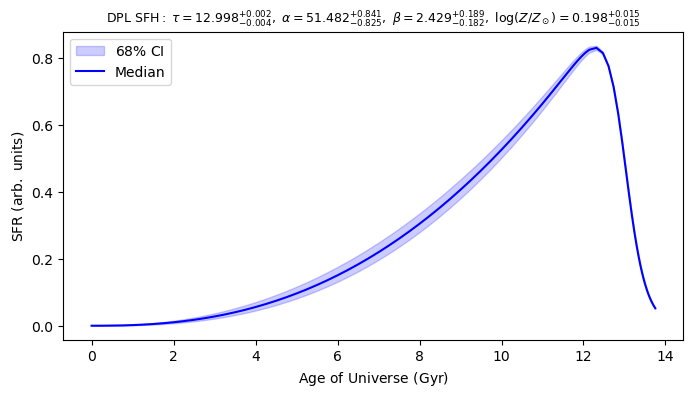

In [14]:
# SFH with 68% CI
cosmic_time = np.max(like.ssp.time) - like.ssp.time
n_use = min(300, len(post))
idx = np.random.choice(len(post), n_use, replace=False)
_sfh_idx = {n: i for i, n in enumerate(names) if n != 'logZsun'}

sfr_grid = np.zeros((n_use, len(cosmic_time)))
for k in range(n_use):
    kw = {n: post[idx[k], j] for n, j in _sfh_idx.items()}
    s = DoublePowerLawSFH(**kw, age_universe=13.8)
    sfr_grid[k] = s.evaluate(like.ssp.time)

sfr_lo = np.percentile(sfr_grid, 16, axis=0)
sfr_med = np.percentile(sfr_grid, 50, axis=0)
sfr_hi = np.percentile(sfr_grid, 84, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(cosmic_time, sfr_lo, sfr_hi, color='b', alpha=0.2, label=r'$68\%$ CI')
ax.plot(cosmic_time, sfr_med, 'b-', lw=1.5, label='Median')
ax.set_xlabel(r'$\mathrm{Age\ of\ Universe\ (Gyr)}$')
ax.set_ylabel(r'$\mathrm{SFR\ (arb.\ units)}$')
_name_map = {'logZsun': r'\log(Z/Z_\odot)', 'tau': r'\tau', 'alpha': r'\alpha', 'beta': r'\beta'}
tparts = []
for i, n in enumerate(names):
    lo, med, hi = np.percentile(post[:, i], [16, 50, 84])
    lbl = _name_map.get(n, n)
    tparts.append(rf'${lbl} = {med:.3f}^{{+{hi-med:.3f}}}_{{-{med-lo:.3f}}}$')
ax.set_title(r'$\mathrm{DPL\ SFH:}\ $' + r'$,\ $'.join(tparts), fontsize=9)
ax.legend(); plt.show()

## 7. Save Results

In [15]:
specfit.save(os.path.join(OUT_DIR, 'specfit_result.fits'))
res.save_result(os.path.join(OUT_DIR, 'mcmc_dpl_result.fits'))
np.save(os.path.join(OUT_DIR, 'posterior_dpl.npy'), post)

print('Saved to', OUT_DIR)
for f in os.listdir(OUT_DIR):
    if os.path.isfile(os.path.join(OUT_DIR, f)):
        print(f'  {f}')

Saved to /home/chengz/Code/opencode/bigs_v2/out_manga_demo
  posterior_dpl.npy
  _demo_sfh.png
  specfit_result.fits
  mcmc_dpl_result.fits


## 8. Using Building-in SFH

In [16]:
mc = MCMCFitter(
    use_jax=True,
    ssp_fits=SSP_FILE,
    specfit_result=specfit,
    sfh_model='delayed',
    wave_range=(3600, 7400),
)
print(f'Likelihood ndof = {mc.likelihood.ndof}')

Likelihood ndof = 2471


In [17]:
%%time
CHAIN_DIR = os.path.join(OUT_DIR, 'chains_manga-9195')
N_LIVE = 1000
mcmc_result = mc.run(n_live=N_LIVE, chain_dir=CHAIN_DIR, frac_remain=0.5)

[ultranest] Sampling 1000 live points from prior ...


[ultranest] Explored until L=-5e+03  697.39 [-4698.7832..-4698.7783]*| it/evals=16084/64381 eff=24.8403% N=660    00 
[ultranest] Likelihood function evaluations: 64424
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -4714 +- 0.07505
[ultranest] Effective samples strategy satisfied (ESS = 1734.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.04 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.46, need <0.5)
[ultranest]   logZ error budget: single: 0.15 bs:0.08 tail:0.45 total:0.46 required:<0.50
[ultranest] done iterating.

logZ = -4714.235 +- 0.474
  single instance: logZ = -4714.235 +- 0.122
  bootstrapped   : logZ = -4714.257 +- 0.146
  tail           : logZ = +- 0.451
insert order U test : converged: True correlation: inf iterations

    t0                  : 10.31 │ ▁▁▁▁▁▁▁▁▁▁▂▃▄▆▅▄▂▁▁▁▁▂▃▆▇▇▅▃▁▁▁▁▁▁▁ ▁ │11.22     10.79 +- 0.15
   

In [18]:
post  = mcmc_result.posterior
names = mc._sampler.param_names
best  = mcmc_result.bestfit

print(f'Posterior samples: {len(post)}')
print(f'log Z = {mcmc_result.log_evidence:.2f}')
for i, name in enumerate(names):
    lo, med, hi = np.percentile(post[:, i], [16, 50, 84])
    print(f'  {name:12s} = {med:8.4f}  [+{hi-med:.4f} / -{med-lo:.4f}]')
if 'logZsun' in best:
    Z = 0.02 * 10 ** best['logZsun']
    print(f'  Z = {Z:.5f}  (Z_solar = 0.02)')

Posterior samples: 16751
log Z = -4714.24
  t0           =  10.8591  [+0.0737 / -0.2311]
  tau          =   0.4430  [+0.0393 / -0.0128]
  logZsun      =   0.1804  [+0.0206 / -0.0453]
  Z = 0.03147  (Z_solar = 0.02)


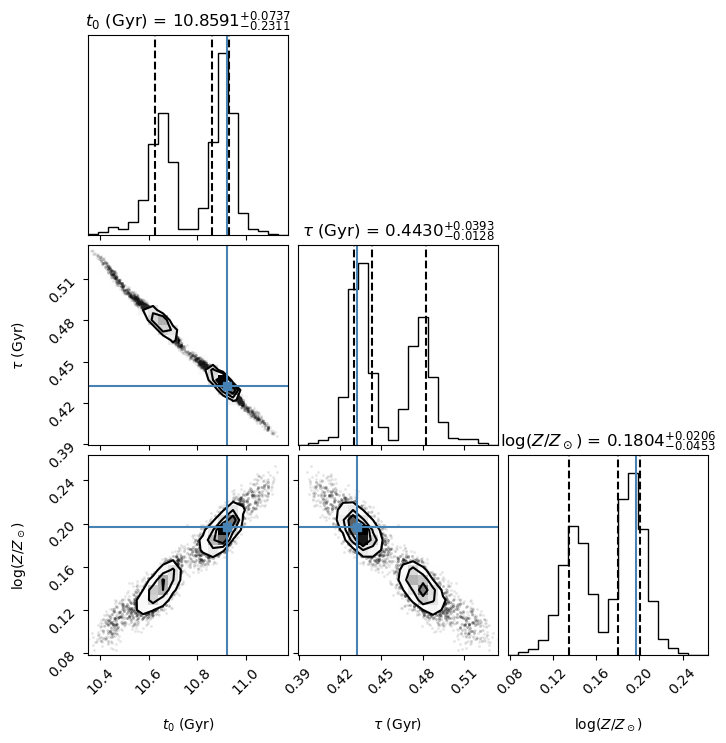

In [19]:
from corner import corner as _corner
_label_map = {'logZsun': r'$\log(Z/Z_\odot)$',
              't0':      r'$t_0\ \mathrm{(Gyr)}$',
              'tau':     r'$\tau\ \mathrm{(Gyr)}$'}
labels = [_label_map.get(n, n) for n in names]
truths = [best[n] for n in names]

fig = _corner(post, labels=labels, truths=truths,
              quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt='.4f')
plt.show()

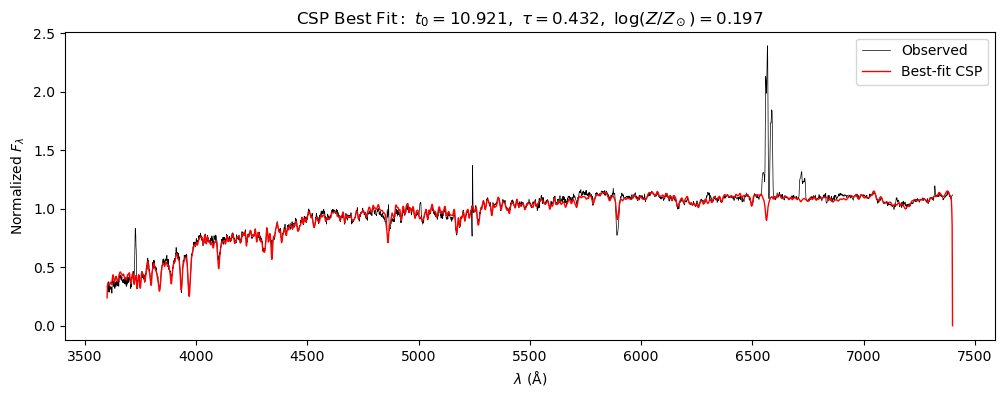

In [20]:
like = mc.likelihood
sfh_best = DelayedExponentialSFH(
    **{k: v for k, v in best.items() if k != 'logZsun'}, age_universe=13.8)
logZ = best.get('logZsun', 0.0)

csp = like.builder.build(logZ, sfh_best)
csp = like.broadener.apply(csp)
n = like._med5500(like.ssp.wave, csp, np.ones_like(csp, dtype=bool), like._n_range)
csp = csp / n; csp = like.dust.apply(csp)
csp_obs = np.interp(like.obs_wave, like.ssp.wave, csp, left=0.0, right=0.0)
n_obs = 1.0 / np.median(like.obs_flux[like.obs_mask])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(like.obs_wave, like.obs_flux * n_obs, 'k-', lw=0.5, label='Observed')
ax.plot(like.obs_wave, csp_obs * n_obs, 'r-', lw=1, label='Best-fit CSP')
ax.set_xlabel(r'$\lambda\ (\mathrm{\AA})$')
ax.set_ylabel(r'Normalized $F_\lambda$'); ax.legend()
_name_map = {'logZsun': r'\log(Z/Z_\odot)', 't0': 't_0', 'tau': r'\tau'}
tparts = [rf'${_name_map.get(k,k)}={v:.3f}$' for k, v in best.items()]
ax.set_title(r'$\mathrm{CSP\ Best\ Fit:}\ $' + r'$,\ $'.join(tparts))
plt.show()

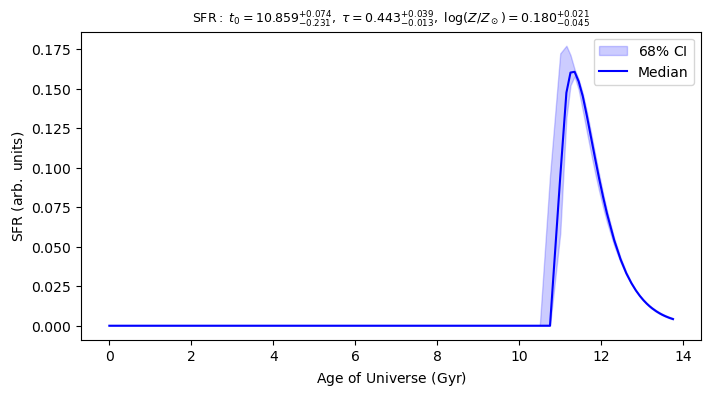

In [21]:
cosmic_time = np.max(like.ssp.time) - like.ssp.time
n_use = min(300, len(post))
idx = np.random.choice(len(post), n_use, replace=False)
_sfh_idx = {n: i for i, n in enumerate(names) if n != 'logZsun'}

sfr_grid = np.zeros((n_use, len(cosmic_time)))
for k in range(n_use):
    kw = {n: post[idx[k], j] for n, j in _sfh_idx.items()}
    s = DelayedExponentialSFH(**kw, age_universe=13.8)
    sfr_grid[k] = s.evaluate(like.ssp.time)

sfr_lo  = np.percentile(sfr_grid, 16, axis=0)
sfr_med = np.percentile(sfr_grid, 50, axis=0)
sfr_hi  = np.percentile(sfr_grid, 84, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(cosmic_time, sfr_lo, sfr_hi, color='b', alpha=0.2, label=r'$68\%$ CI')
ax.plot(cosmic_time, sfr_med, 'b-', lw=1.5, label='Median')
ax.set_xlabel(r'$\mathrm{Age\ of\ Universe\ (Gyr)}$')
ax.set_ylabel(r'$\mathrm{SFR\ (arb.\ units)}$')
tparts_sfh = []
for i, n in enumerate(names):
    lo, med, hi = np.percentile(post[:, i], [16, 50, 84])
    lbl = _name_map.get(n, n)
    tparts_sfh.append(rf'${lbl} = {med:.3f}^{{+{hi-med:.3f}}}_{{-{med-lo:.3f}}}$')
ax.set_title(r'$\mathrm{SFR:}\ $' + r'$,\ $'.join(tparts_sfh), fontsize=9)
ax.legend(); plt.show()